In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score
)


In [7]:
# Load saved model and vectorizer
model = pickle.load(open('../models/cyberbullying_model.pkl', 'rb'))
vectorizer = pickle.load(open('../models/tfidf_vectorizer.pkl', 'rb'))

print("✅ Model and vectorizer loaded successfully!")


✅ Model and vectorizer loaded successfully!


In [8]:
# Load dataset again
df = pd.read_csv("../data/cyberbullying_data_labelled.csv")

# Select correct text column
if 'processed_text' in df.columns:
    text_column = 'processed_text'
elif 'cleaned_text' in df.columns:
    text_column = 'cleaned_text'
else:
    text_column = 'Text'

# Clean dataset
df = df.dropna(subset=[text_column, 'oh_label'])

X = df[text_column].astype(str)
y = df['oh_label'].astype(int)

In [9]:
# Transform using loaded vectorizer
X_tfidf = vectorizer.transform(X)

# Predict using loaded model
y_pred = model.predict(X_tfidf)

In [10]:
# Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.2%}")


Accuracy: 87.13%


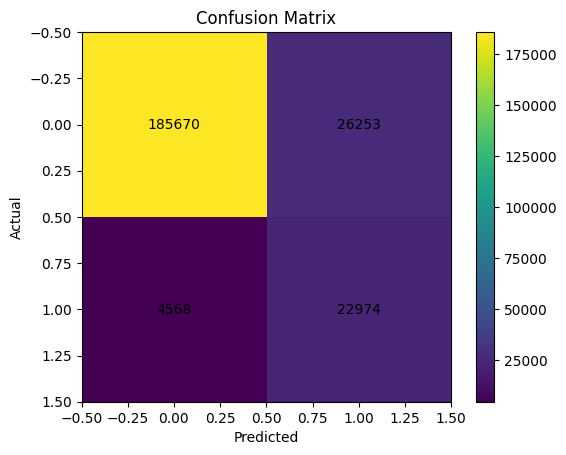

In [11]:
# Confusion Matrix
cm = confusion_matrix(y, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

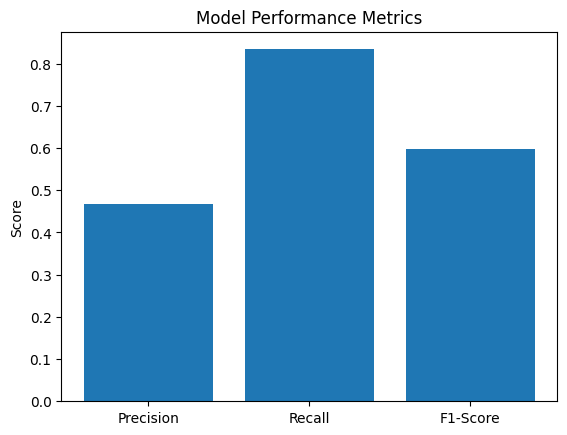

In [12]:

# Precision, Recall, F1 Score
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

metrics = ["Precision", "Recall", "F1-Score"]
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

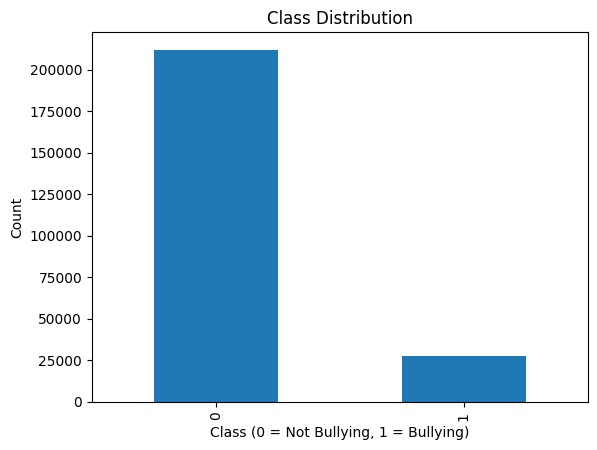

In [13]:
# Class Distribution
df['oh_label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class (0 = Not Bullying, 1 = Bullying)")
plt.ylabel("Count")
plt.show()